In [ ]:
import pandas as pd
df=pd.read_csv("automobile_dataset.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Vehicle_ID       3000 non-null   int64  
 1   Brand            3000 non-null   object 
 2   Model_Year       3000 non-null   int64  
 3   Engine_Size_L    3000 non-null   float64
 4   Fuel_Type        3000 non-null   object 
 5   Transmission     3000 non-null   object 
 6   Mileage_kmpl     3000 non-null   float64
 7   Horsepower       3000 non-null   int64  
 8   Price_USD        3000 non-null   int64  
 9   Units_Sold       3000 non-null   int64  
 10  Region           3000 non-null   object 
 11  Customer_Rating  3000 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 281.4+ KB


In [ ]:
brand_metrics = df.groupby('Brand').agg(
    Average_Price_USD=('Price_USD', 'mean'),
    Total_Units_Sold=('Units_Sold', 'sum')
).reset_index()
print(brand_metrics.head())

      Brand  Average_Price_USD  Total_Units_Sold
0      Ford       29264.608200            110175
1     Honda       28405.158986            112945
2   Hyundai       28831.055300            113426
3  Mahindra       28184.752336            108302
4    Maruti       29304.498795            104133


In [ ]:
df['Revenue'] = df['Price_USD'] * df['Units_Sold']
print(df[['Price_USD', 'Units_Sold', 'Revenue']].head())

   Price_USD  Units_Sold   Revenue
0      38255         398  15225490
1      44094         330  14551020
2      33221         107   3554647
3       8719         221   1926899
4      25906         362   9377972


In [ ]:
region_revenue = df.groupby('Region')['Revenue'].sum()
print(region_revenue)

Region
Asia             5366967818
Europe           5334728026
North America    5766429140
South America    5535225627
Name: Revenue, dtype: int64


In [ ]:
total_revenue = region_revenue.sum()
region_revenue_percentage = (region_revenue / total_revenue) * 100
print(region_revenue_percentage)

Region
Asia             24.391593
Europe           24.245071
North America    26.207050
South America    25.156285
Name: Revenue, dtype: float64


In [ ]:
fuel_type_revenue = df.groupby('Fuel_Type')['Revenue'].sum()
print(fuel_type_revenue)

Fuel_Type
Diesel      5454779707
Electric    5326852365
Hybrid      5401946550
Petrol      5819771989
Name: Revenue, dtype: int64


In [ ]:
highest_revenue_fuel_type = fuel_type_revenue.idxmax()
highest_revenue_value = fuel_type_revenue.max()

print(f"The fuel type with the highest total revenue is: {highest_revenue_fuel_type}")
print(f"Total Revenue for {highest_revenue_fuel_type}: {highest_revenue_value}")

The fuel type with the highest total revenue is: Petrol
Total Revenue for Petrol: 5819771989


In [ ]:
brand_fuel_price_pivot = df.pivot_table(index='Brand', columns='Fuel_Type', values='Price_USD', aggfunc='mean')
print(brand_fuel_price_pivot)

Fuel_Type        Diesel      Electric        Hybrid        Petrol
Brand                                                            
Ford       27768.855932  30601.951923  29983.536842  29011.467213
Honda      29871.944444  27507.450980  27473.710526  28762.781818
Hyundai    27687.614679  28477.238095  29431.657407  29696.419643
Mahindra   27086.820000  29035.154639  28775.327434  27850.593220
Maruti     28178.625000  30501.080000  29401.394231  29116.226087
Tata       28270.700000  28098.232323  28311.329670  30574.903509
Toyota     30859.317308  29853.437500  29831.071429  28172.152542


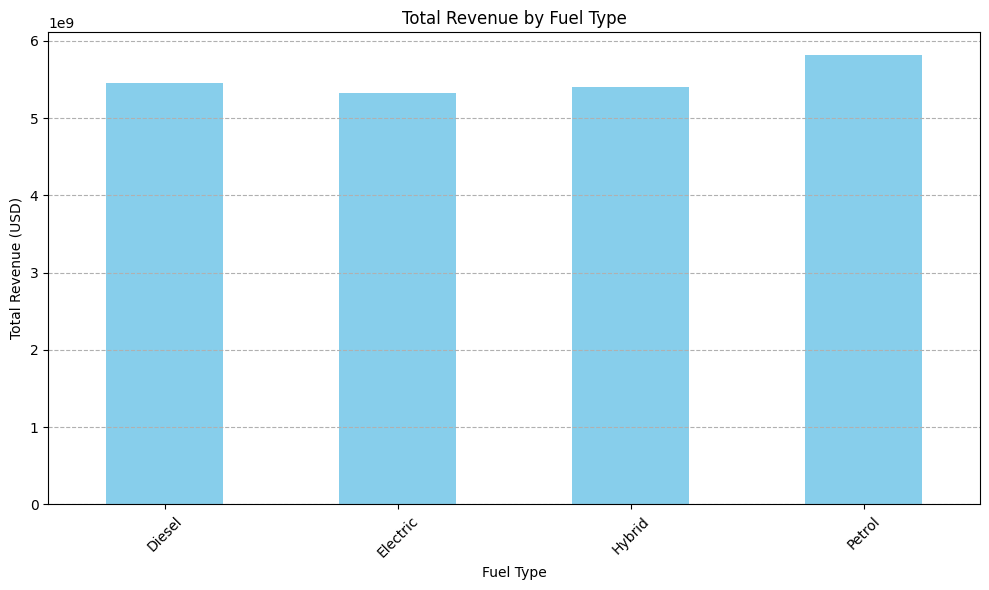

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
fuel_type_revenue.plot(kind='bar', color='skyblue')
plt.title('Total Revenue by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
yearly_sales = df.groupby(['Brand', 'Model_Year'])['Units_Sold'].sum().reset_index()
print(yearly_sales.head())

  Brand  Model_Year  Units_Sold
0  Ford        2010        8267
1  Ford        2011        5341
2  Ford        2012        6984
3  Ford        2013        5065
4  Ford        2014        9180


In [ ]:
yearly_sales = yearly_sales.sort_values(by=['Brand', 'Model_Year'])
yearly_sales['Sales_Change'] = yearly_sales.groupby('Brand')['Units_Sold'].diff()
print(yearly_sales.head(10))

  Brand  Model_Year  Units_Sold  Sales_Change
0  Ford        2010        8267           NaN
1  Ford        2011        5341       -2926.0
2  Ford        2012        6984        1643.0
3  Ford        2013        5065       -1919.0
4  Ford        2014        9180        4115.0
5  Ford        2015        8048       -1132.0
6  Ford        2016        8869         821.0
7  Ford        2017       11476        2607.0
8  Ford        2018        7093       -4383.0
9  Ford        2019       11197        4104.0


In [ ]:
latest_years = yearly_sales.groupby('Brand')['Model_Year'].nlargest(2).reset_index()
declining_sales_df = pd.merge(yearly_sales, latest_years, on=['Brand', 'Model_Year'], how='inner')
print(declining_sales_df.head(10))

      Brand  Model_Year  Units_Sold  Sales_Change  level_1
0      Ford        2022        7307        -302.0       12
1      Ford        2023        7437         130.0       13
2     Honda        2022        6751       -3528.0       26
3     Honda        2023        8232        1481.0       27
4   Hyundai        2022        7736       -1316.0       40
5   Hyundai        2023        7493        -243.0       41
6  Mahindra        2022        9004        2249.0       54
7  Mahindra        2023        6925       -2079.0       55
8    Maruti        2022        7426       -1187.0       68
9    Maruti        2023        6681        -745.0       69


In [ ]:
latest_sales = declining_sales_df.loc[declining_sales_df.groupby('Brand')['Model_Year'].idxmax()]
declining_brands = latest_sales[latest_sales['Sales_Change'] < 0]

print("Brands with declining sales in their latest available year:")
print(declining_brands[['Brand', 'Model_Year', 'Sales_Change']])

Brands with declining sales in their latest available year:
       Brand  Model_Year  Sales_Change
5    Hyundai        2023        -243.0
7   Mahindra        2023       -2079.0
9     Maruti        2023        -745.0
11      Tata        2023        -491.0
13    Toyota        2023       -2750.0


In [ ]:
bins = [0, 20000, 40000, df['Price_USD'].max() + 1]
labels = ['Low', 'Medium', 'High']
df['Price_Category'] = pd.cut(df['Price_USD'], bins=bins, labels=labels, right=False)

print(df[['Price_USD', 'Price_Category']].head())

   Price_USD Price_Category
0      38255         Medium
1      44094           High
2      33221         Medium
3       8719            Low
4      25906         Medium


In [ ]:
print('\nPrice Category Distribution:')
print(df['Price_Category'].value_counts())


Price Category Distribution:
Price_Category
Medium    1489
Low        827
High       684
Name: count, dtype: int64


In [ ]:
brand_revenue = df.groupby('Brand')['Revenue'].sum()
print(brand_revenue)

Brand
Ford        3255806205
Honda       3222697335
Hyundai     3172624306
Mahindra    3035661083
Maruti      3089103665
Tata        2880955042
Toyota      3346502975
Name: Revenue, dtype: int64


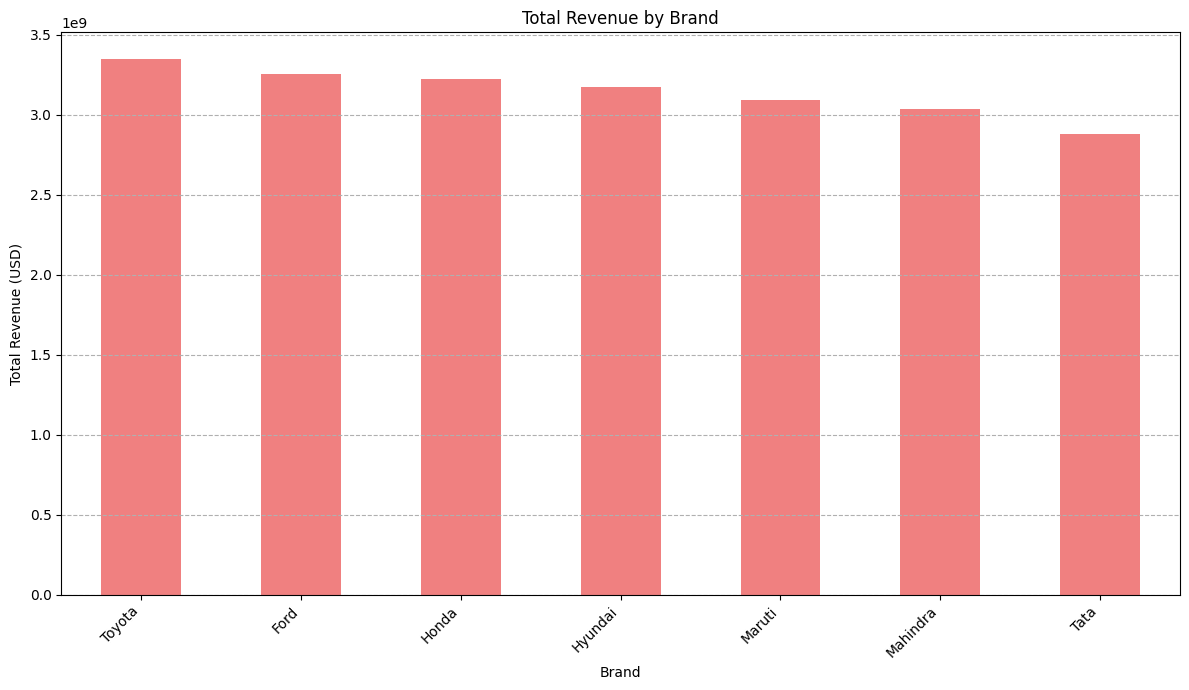

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
brand_revenue.sort_values(ascending=False).plot(kind='bar', color='lightcoral')
plt.title('Total Revenue by Brand')
plt.xlabel('Brand')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()